In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
!pip install nolds -q
import nolds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 5.7 MB/s eta 0:00:00


In [ ]:
bands = {
    "HF": (0.15, 0.4),
    "LF": (0.04, 0.15),
    "VLF": (0.015, 0.04),
    # "ULF": (0.005, 0.015)
}

In [ ]:
delta_t = 0.25
fs = 1 / delta_t
left_interval_border = bands['VLF'][0]
right_interval_border = bands['HF'][1]

In [ ]:
def load_rr_intervals(filename):
  rr_intervals = pd.read_csv(filename).to_numpy(dtype=float)
  rr_intervals = rr_intervals/1000
  time = np.cumsum(rr_intervals)
  time = time - time[0]
  cubic_splie = CubicSpline(time, rr_intervals)
  time_interpolated = np.arange(time[0], time[-1], delta_t)
  rr_interpolated = [item[0] for item in cubic_splie(time_interpolated)]
  return rr_interpolated, time_interpolated

In [ ]:
filename = '1_f.csv'
rr_interpolated, time_interpolated = load_rr_intervals(filename)

## Рассчёт показателя Херста

Первый прототип

In [ ]:
def bad_hurst_exponent(signal):
  r_s = np.zeros(len(signal))
  rr = signal.copy()
  for i in range(1, len(signal) + 1):
    y = rr[:i] - np.mean(rr[:i])
    z = np.cumsum(y)
    r_n = max(z) - min(z)
    r_s[i-1] = r_n / np.std(rr[:i])
  return r_s

Рабочее решение

In [ ]:
def calculate_rs(signal_part):
  mean = signal_part.mean()
  y = signal_part - mean
  z = np.cumsum(y)
  r_n = max(z) - min(z)
  return r_n / np.std(signal_part, ddof=1)

def calculcate_rs_for_n(signal, n):
  data = np.array(signal)
  data = data[:len(data) - len(data)%n]
  splitted = data.reshape((-1, n))
  rs = np.zeros(len(data) // n)
  for i, signal_part in enumerate(splitted):
    rs[i] = calculate_rs(signal_part)
  return rs.mean()

def calculate_hurst_exponent(signal):
  # nvals = np.arange(1, len(rr_interpolated)+1, 1)
  nvals = logmid_n(len(signal), ratio=1/4.0, nsteps=15)
  rs_n = np.zeros(len(nvals))
  for i, n in enumerate(nvals):
    rs_n[i] = calculcate_rs_for_n(signal, n)
  H = np.polyfit(np.log(nvals[1:]), np.log(rs_n[1:]), 1)[0]
  return H, rs_n, nvals

def logmid_n(max_n, ratio=1/4.0, nsteps=15):
  l = np.log(max_n)
  span = l * ratio
  start = l * (1 - ratio) * 0.5
  midrange = start + 1.0*np.arange(nsteps)/nsteps*span
  nvals = np.round(np.exp(midrange)).astype("int32")
  return np.unique(nvals)

In [ ]:
def hurst_value_interpretation(H):
  if H < 0.5:
    print(f"H = {H:.3f} < 0.5")
    print("Процесс характеризуется антиперсистентностью — любая тенденция стремится смениться противоположной")
  elif np.round(H, 2) == 0.5:
    print(f"H = {H:.3f} == 0.5")
    print("Явной тенденции не выражено")
  else:
    print(f"H = {H:.3f} > 0.5")
    print("Ряд сохраняют имеющуюся тенденцию, то есть возрастание в прошлом более вероятно приводит к возрастанию в дальнейшем")

In [ ]:
H_custom, rs_n, nvals = calculate_hurst_exponent(rr_interpolated)

### Сравнение с библиотечной реализацией

In [ ]:
H_nolds = nolds.hurst_rs(rr_interpolated, corrected=False)

In [ ]:
print("H (custom):", H_custom)
print("H (nolds):", H_nolds)
hurst_value_interpretation(H_custom)

H (custom): 0.8184230269993271
H (nolds): 0.8170412537032404
H = 0.818 > 0.5
Ряд сохраняют имеющуюся тенденцию, то есть возрастание в прошлом более вероятно приводит к возрастанию в дальнейшем


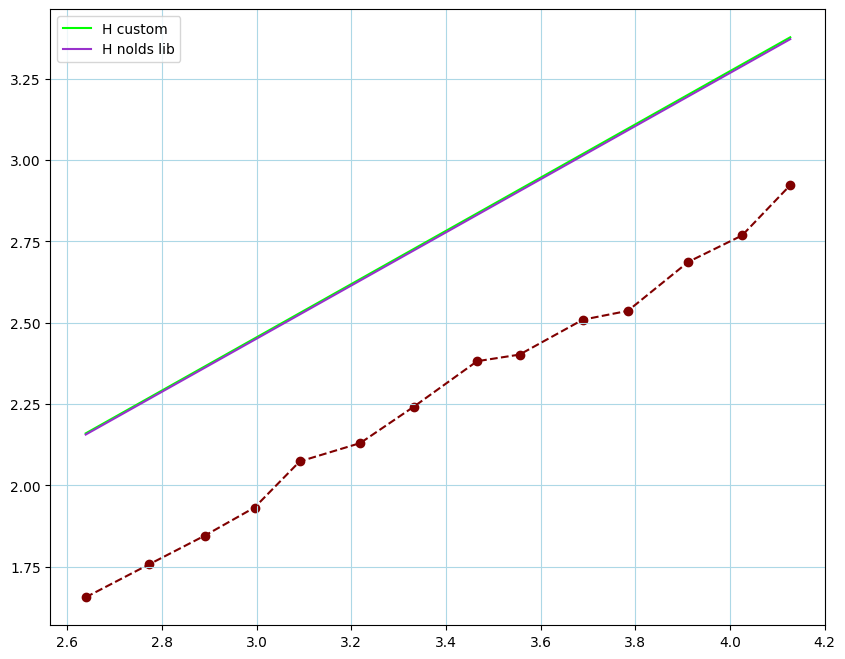

In [ ]:
plt.figure(figsize=(10, 8))
plt.grid(color='lightblue')

plt.plot(np.log(nvals[1:]), np.log(rs_n[1:]), color='maroon', linestyle='dashed')
plt.scatter(np.log(nvals[1:]), np.log(rs_n[1:]), color='maroon')
h_line_custom = [H_custom * x for x in np.log(nvals)]
h_line_nolds = [H_nolds * x for x in np.log(nvals)]

plt.plot(np.log(nvals[1:]), (h_line_custom[1:]), color='lime', label='H custom')
plt.plot(np.log(nvals[1:]), (h_line_nolds[1:]), color='darkorchid', label='H nolds lib')
plt.legend()

## Тестовый файл 2

In [ ]:
filename2 = '0030.vf2'
rr_interpolated2, time_interpolated2 = load_rr_intervals(filename2)
H_custom2, rs_n2, nvals2 = calculate_hurst_exponent(rr_interpolated2)
H_nolds2 = nolds.hurst_rs(rr_interpolated2, corrected=False)
print("H (custom):", H_custom2)
print("H (nolds):", H_nolds2)
hurst_value_interpretation(H_custom2)

H (custom): 0.6845158599688511
H (nolds): 0.7008553896431816
H = 0.685 > 0.5
Ряд сохраняют имеющуюся тенденцию, то есть возрастание в прошлом более вероятно приводит к возрастанию в дальнейшем


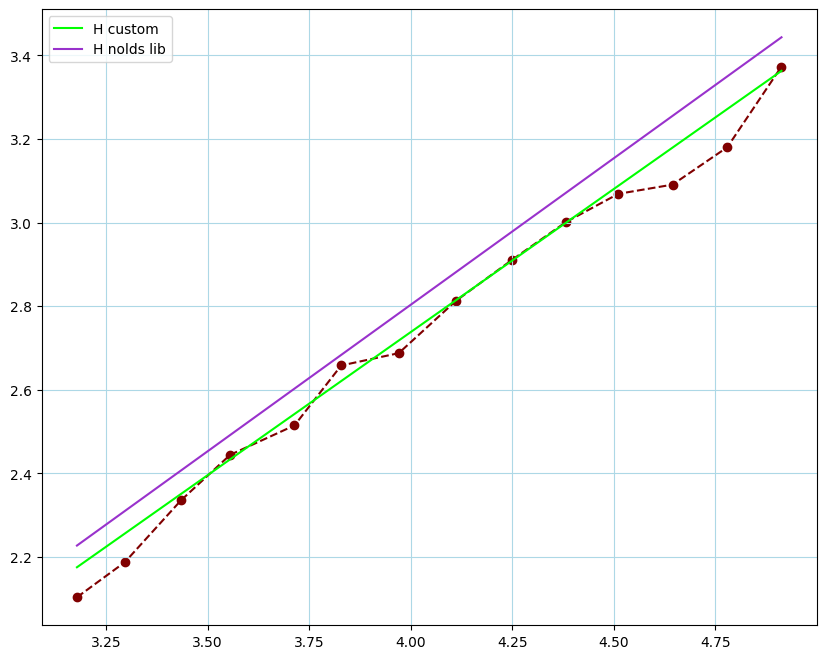

In [ ]:
plt.figure(figsize=(10, 8))
plt.grid(color='lightblue')
plt.plot(np.log(nvals2[1:]), np.log(rs_n2[1:]), color='maroon', linestyle='dashed')
plt.scatter(np.log(nvals2[1:]), np.log(rs_n2[1:]), color='maroon')

h_line_custom2 = [H_custom2 * x for x in np.log(nvals2)]
h_line_nolds2 = [H_nolds2 * x for x in np.log(nvals2)]

plt.plot(np.log(nvals2[1:]), (h_line_custom2[1:]), color='lime', label='H custom')
plt.plot(np.log(nvals2[1:]), (h_line_nolds2[1:]), color='darkorchid', label='H nolds lib')
plt.legend()

## Тестовый файл 3

In [ ]:
filename3 = '0071.vf1'
rr_interpolated3, time_interpolated3 = load_rr_intervals(filename3)
H_custom3, rs_n3, nvals3 = calculate_hurst_exponent(rr_interpolated3)
# H_nolds3_same_nvals = nolds.hurst_rs(rr_interpolated3, nvals=nvals3)
H_nolds3 = nolds.hurst_rs(rr_interpolated3, corrected=False)

print("H (custom):", H_custom3)
print("H (nolds):", H_nolds3)
# print("H (nolds) same nvals:", H_nolds3_same_nvals)
hurst_value_interpretation(H_custom3)

H (custom): 0.4392122716420432
H (nolds): 0.4434055789397078
H = 0.439 < 0.5
Процесс характеризуется антиперсистентностью — любая тенденция стремится смениться противоположной


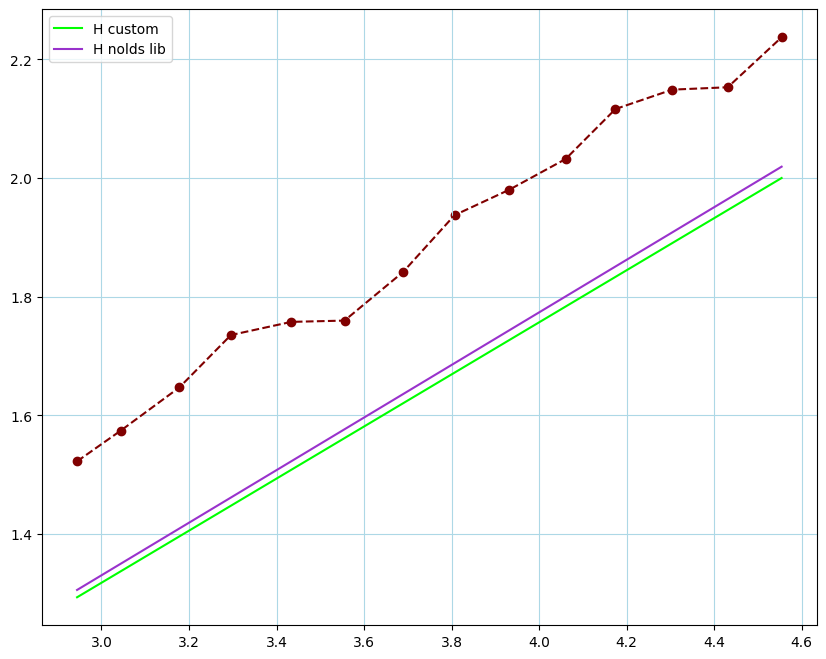

In [ ]:
plt.figure(figsize=(10, 8))
plt.grid(color='lightblue')
plt.plot(np.log(nvals3[1:]), np.log(rs_n3[1:]), color='maroon', linestyle='dashed')
plt.scatter(np.log(nvals3[1:]), np.log(rs_n3[1:]), color='maroon')

h_line_custom3 = [H_custom3 * x for x in np.log(nvals3)]
h_line_nolds3 = [H_nolds3 * x for x in np.log(nvals3)]

plt.plot(np.log(nvals3[1:]), (h_line_custom3[1:]), color='lime', label='H custom')
plt.plot(np.log(nvals3[1:]), (h_line_nolds3[1:]), color='darkorchid', label='H nolds lib')
# plt.plot(np.log(nvals3[1:]), (h_line_nolds_same3[1:]), color='navy', label='H nolds lib (same nvals)')

plt.legend()

## Показатель флуктуации

In [ ]:
def remove_linear_trend(signal):
  time = np.arange(len(signal))
  coefs = np.polyfit(time, signal, 1)
  detrend = signal - np.polyval(coefs, time)
  return detrend

def remove_moving_average_trend(signal, window=5):
  kernel = np.ones(window) / window
  trend = np.convolve(signal, kernel, mode='same')
  detrended = signal - trend
  return detrended

def logarithmic_n(min_n, max_n, factor):
  max_i = int(np.floor(np.log(1.0 * max_n / min_n) / np.log(factor)))
  ns = [min_n]
  for i in range(max_i + 1):
    n = int(np.floor(min_n * (factor ** i)))
    if n > ns[-1]:
      ns.append(n)
  return ns

In [ ]:
def count_fluctuations(signal_parts):
  n = signal_parts.shape[1]
  detrended_parts = [remove_linear_trend(signal)**2 for signal in signal_parts]
  fluctuations = np.sum(detrended_parts, axis=1) / n
  fluctuations = np.sqrt(np.sum(fluctuations) / len(fluctuations))
  return fluctuations

def detrended_fluctuation_analysis(signal, step = 10):
  nvals = logarithmic_n(4, 0.1 * len(signal), 1.2)
  # nvals = np.arange(4, len(signal)//2, step)
  centrered_signal = signal - np.mean(signal)
  cumsum_signal = np.cumsum(centrered_signal)
  fluctuations = np.zeros(len(nvals))
  for i, nval in enumerate(nvals):
    signal_parts = np.array([cumsum_signal[j:j+nval] for j in range(0, len(cumsum_signal) - nval, nval // 2) ])
    fluctuations[i] = count_fluctuations(signal_parts)
  coef = np.polyfit(np.log(nvals), np.log(fluctuations), 1)[0]
  return coef, fluctuations, nvals

In [ ]:
def alpha_interpretation(alpha):
  if np.round(alpha, 2) == 1.5:
    print(f'{alpha:.3f} == 1.5')
    print("Броуновский шум, красный шум")
  elif np.round(alpha, 2) == 1:
    print(f'{alpha:.3f} == 1.5')
    print("Розовый шум")
  elif alpha > 1:
    print(f'{alpha:.3f} > 1')
    print("Сигнал нестационарный, неограниченный")
  elif alpha > 0.5 and alpha < 1:
    print(f'{alpha:.3f} > 0.5')
    print("Сигнал коррелирует")
  elif np.round(alpha, 2) == 0.5:
    print(f'{alpha:.3f} == 0.5')
    print("Сигнал не коррелирует, белый шум")
  elif alpha < 0.5:
    print(f'{alpha:.3f} < 0.5')
    print("Антикорреляция")


### Файл 1

In [ ]:
alpha_custom, fluc, a_nvals = detrended_fluctuation_analysis(rr_interpolated)
alpha_nolds = nolds.dfa(rr_interpolated)

print("alpha (custom):", alpha_custom)
print("alpha (nolds):", alpha_nolds)
alpha_interpretation(alpha_custom)

alpha (custom): 1.1143792521674667
alpha (nolds): 1.1143792521674671
1.114 > 1
Сигнал нестационарный, неограниченный


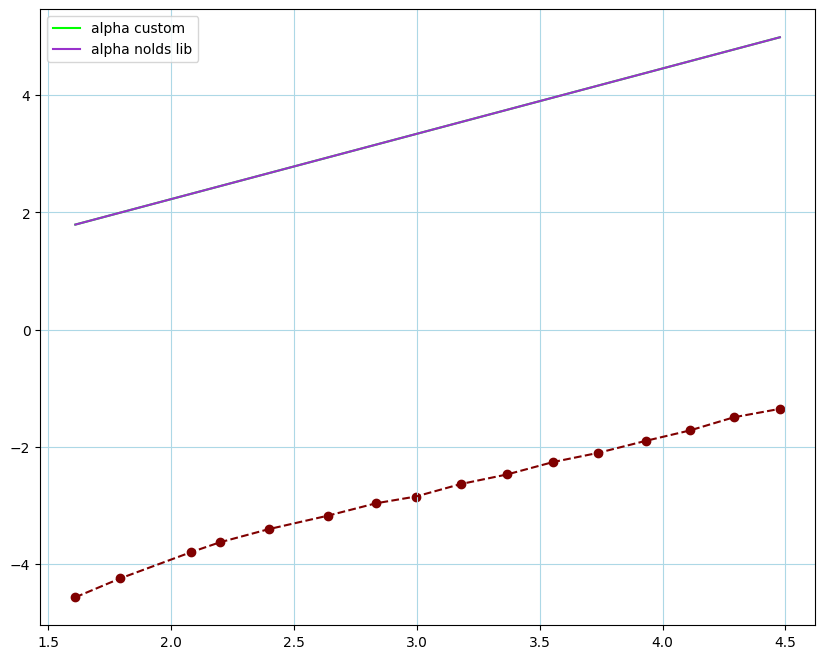

In [ ]:
plt.figure(figsize=(10, 8))
plt.grid(color='lightblue')
plt.plot(np.log(a_nvals[1:]), np.log(fluc[1:]), color='maroon', linestyle='dashed')
plt.scatter(np.log(a_nvals[1:]), np.log(fluc[1:]), color='maroon')

a_line_custom1 = [alpha_custom * x for x in np.log(a_nvals)]
a_line_nolds1 = [alpha_nolds * x for x in np.log(a_nvals)]

plt.plot(np.log(a_nvals[1:]), (a_line_custom1[1:]), color='lime', label='alpha custom')
plt.plot(np.log(a_nvals[1:]), (a_line_nolds1[1:]), color='darkorchid', label='alpha nolds lib')
# plt.plot(np.log(nvals3[1:]), (h_line_nolds_same3[1:]), color='navy', label='H nolds lib (same nvals)')

plt.legend()

### Файл 2

In [ ]:
alpha_custom2, fluc2, a_nvals2 = detrended_fluctuation_analysis(rr_interpolated2)
alpha_nolds2 = nolds.dfa(rr_interpolated2)

print("alpha (custom):", alpha_custom2)
print("alpha (nolds):", alpha_nolds2)
alpha_interpretation(alpha_custom2)

alpha (custom): 0.7398280018868774
alpha (nolds): 0.7398280018868777
0.740 > 0.5
Сигнал коррелирует


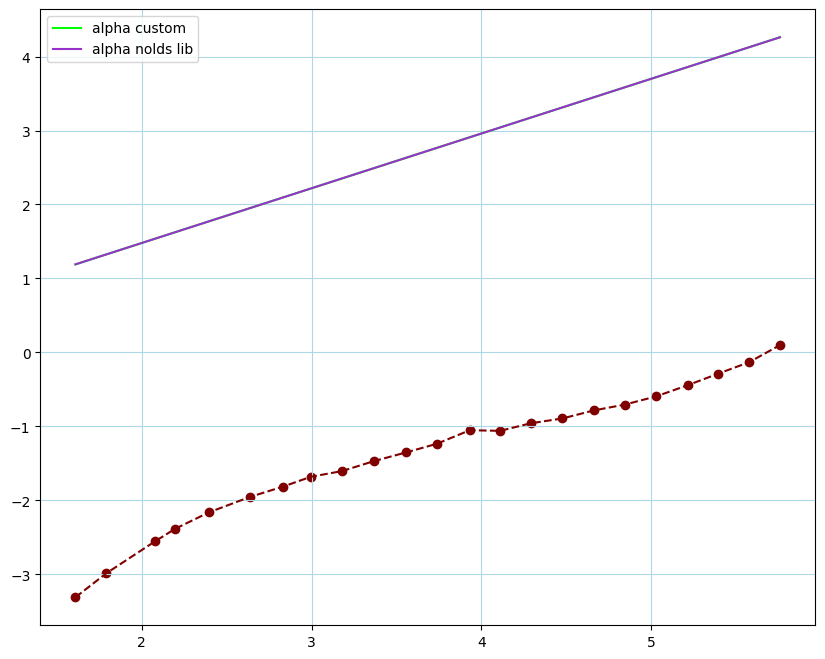

In [ ]:
plt.figure(figsize=(10, 8))
plt.grid(color='lightblue')
plt.plot(np.log(a_nvals2[1:]), np.log(fluc2[1:]), color='maroon', linestyle='dashed')
plt.scatter(np.log(a_nvals2[1:]), np.log(fluc2[1:]), color='maroon')

a_line_custom2 = [alpha_custom2 * x for x in np.log(a_nvals2)]
a_line_nolds2 = [alpha_nolds2 * x for x in np.log(a_nvals2)]

plt.plot(np.log(a_nvals2[1:]), (a_line_custom2[1:]), color='lime', label='alpha custom')
plt.plot(np.log(a_nvals2[1:]), (a_line_nolds2[1:]), color='darkorchid', label='alpha nolds lib')
# plt.plot(np.log(nvals3[1:]), (h_line_nolds_same3[1:]), color='navy', label='H nolds lib (same nvals)')

plt.legend()

### Файл 3

In [ ]:
alpha_custom3, fluc3, a_nvals3 = detrended_fluctuation_analysis(rr_interpolated3)
alpha_nolds3 = nolds.dfa(rr_interpolated3)

print("alpha (custom):", alpha_custom3)
print("alpha (nolds):", alpha_nolds3)
alpha_interpretation(alpha_custom3)

alpha (custom): 0.46708103781769367
alpha (nolds): 0.4291264596306123
0.467 < 0.5
Антикорреляция


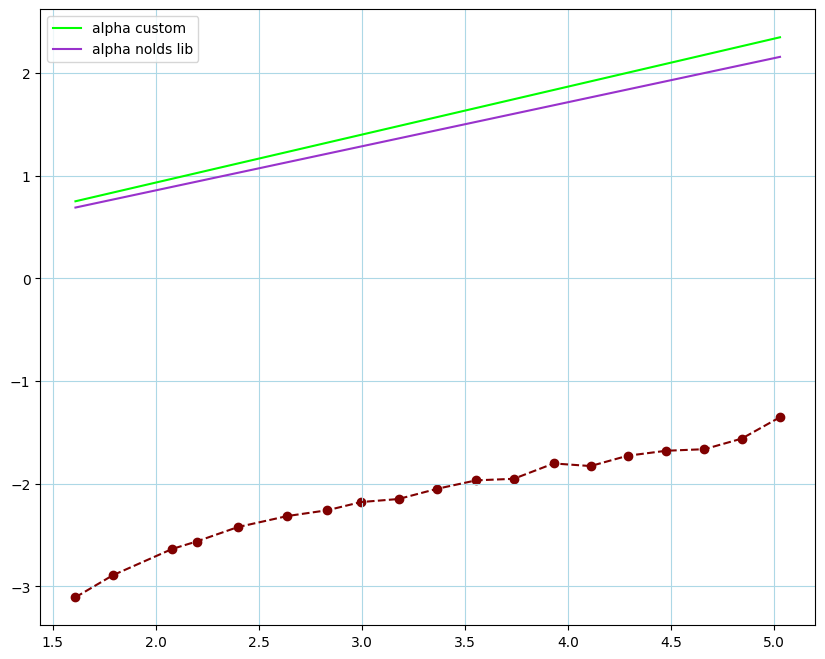

In [ ]:
plt.figure(figsize=(10, 8))
plt.grid(color='lightblue')
plt.plot(np.log(a_nvals3[1:]), np.log(fluc3[1:]), color='maroon', linestyle='dashed')
plt.scatter(np.log(a_nvals3[1:]), np.log(fluc3[1:]), color='maroon')

a_line_custom3 = [alpha_custom3 * x for x in np.log(a_nvals3)]
a_line_nolds3 = [alpha_nolds3 * x for x in np.log(a_nvals3)]

plt.plot(np.log(a_nvals3[1:]), (a_line_custom3[1:]), color='lime', label='alpha custom')
plt.plot(np.log(a_nvals3[1:]), (a_line_nolds3[1:]), color='darkorchid', label='alpha nolds lib')
plt.legend()

## Выводы


Реализованные методы рассчёта параметра Херса и показателя флуктуаций дают значения схожие с библиотечными функциями.